# IaC Benchmark Dataset — Exploratory Analysis

**Dataset:** `final_benchmark_deployable_stratified.csv`  
**Scope:** 229 deployable Terraform templates, stratified across 5 difficulty bands.  
Each template was validated end-to-end (`init → validate → apply → reset`) and scored on complexity
using Lines-of-Code (LoC), resource count, parameter count, and security hardness (PPR).

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "#F7F6F2",
    "axes.facecolor": "#F9F8F5",
    "axes.edgecolor": "#D4D1CA",
    "axes.labelcolor": "#28251D",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.color": "#7A7974",
    "ytick.color": "#7A7974",
    "grid.color": "#DCD9D5",
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
    "font.family": "DejaVu Sans",
    "legend.framealpha": 0.9,
    "legend.edgecolor": "#D4D1CA",
})

BAND_ORDER  = ["Very Easy", "Easy", "Moderate", "Hard", "Very Hard"]
BAND_COLORS = {
    "Very Easy": "#4f98a3",
    "Easy":      "#6daa45",
    "Moderate":  "#d19900",
    "Hard":      "#da7101",
    "Very Hard": "#a12c7b",
}

df = pd.read_csv("iac_benchmark/dataset/final_benchmark_deployable_stratified.csv")
df["final_difficulty_band"] = pd.Categorical(
    df["final_difficulty_band"], categories=BAND_ORDER, ordered=True
)
df.sort_values("final_difficulty_band", inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Loaded {len(df):,} templates across {df['final_difficulty_band'].nunique()} difficulty bands.")
df.head(3)


Loaded 229 templates across 5 difficulty bands.


,source_slug,source_category,primary_cloud,licence_spdx,dest_file,content_hash,github_url,loc,tokens,difficulty,...,composite_level,ppr_pct,ppr_hardness,loc_rank,res_rank,par_rank,ppr_hard_rank,final_difficulty_score,final_difficulty_level,final_difficulty_band
0,Tianyi2/IRIS,benchmark-source,multi,Apache-2.0,multi_root_templates/Tianyi2__IRIS/data__terra...,b9563ace0312386c80c4282a9ed3410c6d7b241aaef945...,https://github.com/Tianyi2/IRIS/tree/HEAD/data...,8,67,1,...,2,100.0,0.0,0.072052,0.069869,0.650655,0.502183,0.072052,1,Very Easy
1,Tianyi2/IRIS,benchmark-source,multi,Apache-2.0,multi_root_templates/Tianyi2__IRIS/data__terra...,96856c7d0c61a12c7d64e364b13a878fa327714715c6c0...,https://github.com/Tianyi2/IRIS/tree/HEAD/data...,13,81,1,...,1,100.0,0.0,0.168122,0.366812,0.198690,0.502183,0.168122,1,Very Easy
2,Tianyi2/IRIS,benchmark-source,multi,Apache-2.0,multi_root_templates/Tianyi2__IRIS/data__terra...,31dd31bc79e6fa8dfef363a8878a12661feb854207f6c0...,https://github.com/Tianyi2/IRIS/tree/HEAD/data...,6,35,1,...,2,100.0,0.0,0.037118,0.069869,0.810044,0.502183,0.037118,1,Very Easy


## 1 · Benchmark Overview Table

A structured summary of all 36 columns, grouped by category.


In [2]:
column_meta = {
    # Provenance
    "source_slug":           ("Provenance",    "GitHub repository slug that provided the template"),
    "source_category":       ("Provenance",    "Role of the source: benchmark-source or educational"),
    "primary_cloud":         ("Provenance",    "Target cloud provider (multi / aws)"),
    "licence_spdx":          ("Provenance",    "SPDX licence identifier of the source repository"),
    "dest_file":             ("Provenance",    "Relative path of the Terraform file in the benchmark corpus"),
    "github_url":            ("Provenance",    "Direct GitHub URL to the template"),
    "content_hash":          ("Provenance",    "SHA-256 hash of the file content for deduplication"),
    # Complexity
    "loc":                   ("Complexity",    "Lines of code (non-blank, non-comment)"),
    "tokens":                ("Complexity",    "Total HCL token count (lexer output)"),
    "n_resources":           ("Complexity",    "Number of `resource` blocks declared"),
    "n_params":              ("Complexity",    "Number of `variable` / `locals` declarations"),
    "difficulty":            ("Complexity",    "Legacy 1-5 difficulty label from source metadata"),
    # Difficulty scoring
    "loc_rank":              ("Scoring",       "Percentile rank of LoC within the full corpus (0–1)"),
    "res_rank":              ("Scoring",       "Percentile rank of n_resources within the corpus"),
    "par_rank":              ("Scoring",       "Percentile rank of n_params within the corpus"),
    "ppr_hard_rank":         ("Scoring",       "Percentile rank of PPR hardness within the corpus"),
    "final_difficulty_score":("Scoring",       "Composite difficulty score (weighted average of ranks, 0–1)"),
    "final_difficulty_level":("Scoring",       "Ordinal difficulty level 1 (Very Easy) – 5 (Very Hard)"),
    "final_difficulty_band": ("Scoring",       "Human-readable label: Very Easy / Easy / Moderate / Hard / Very Hard"),
    "composite_level":       ("Scoring",       "Intermediate composite level (1–5) from resource + param ranks"),
    # Validation
    "hcl2_valid":            ("Validation",    "HCL2 syntax parse succeeded (all True in this deployable subset)"),
    "tflint_pass":           ("Validation",    "tflint linting passed with no errors"),
    "yaml_valid":            ("Validation",    "Embedded YAML blocks are valid (where present)"),
    "targets_aws":           ("Validation",    "Template targets AWS (provider / data sources detected)"),
    "init_ok":               ("Validation",    "terraform init completed without error"),
    "validate_ok":           ("Validation",    "terraform validate passed"),
    "apply_ok":              ("Validation",    "terraform apply completed (real deployment succeeded)"),
    "reset_ok":              ("Validation",    "terraform destroy / reset cleaned up all resources"),
    "backend":               ("Validation",    "Terraform backend used during deployment (e.g., aws)"),
    "checked_at":            ("Validation",    "ISO-8601 timestamp of the deployment check"),
    "deploy_error":          ("Validation",    "Error message if deployment failed (NaN = success)"),
    "deploy_stage":          ("Validation",    "Stage at which deployment failed (NaN = success)"),
    # Security
    "checkov_score":         ("Security",      "Fraction of Checkov security checks that passed (0–1)"),
    "trivy_ppr":             ("Security",      "Trivy pass/fail ratio for IaC misconfig checks (0–1)"),
    "ppr_pct":               ("Security",      "PPR percentage: proportion of Trivy checks passing (%)"),
    "ppr_hardness":          ("Security",      "Inverted PPR — higher = more security findings (0–1)"),
}

rows = [
    {"Column": col, "Category": meta[0], "Description": meta[1]}
    for col, meta in column_meta.items()
]
meta_df = pd.DataFrame(rows)

# Display grouped
for cat, grp in meta_df.groupby("Category"):
    display(grp.style
        .hide(axis="index")
        .set_caption(f"<b>{cat}</b>")
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "13px"), ("text-align", "left"), ("padding-bottom", "4px")]},
            {"selector": "th", "props": [("background-color", "#CEDCD8"), ("color", "#28251D"), ("font-weight", "600")]},
            {"selector": "tr:nth-child(even)", "props": [("background-color", "#F3F0EC")]},
        ])
    )


Column,Category,Description
loc,Complexity,"Lines of code (non-blank, non-comment)"
tokens,Complexity,Total HCL token count (lexer output)
n_resources,Complexity,Number of `resource` blocks declared
n_params,Complexity,Number of `variable` / `locals` declarations
difficulty,Complexity,Legacy 1-5 difficulty label from source metadata


Column,Category,Description
source_slug,Provenance,GitHub repository slug that provided the template
source_category,Provenance,Role of the source: benchmark-source or educational
primary_cloud,Provenance,Target cloud provider (multi / aws)
licence_spdx,Provenance,SPDX licence identifier of the source repository
dest_file,Provenance,Relative path of the Terraform file in the benchmark corpus
github_url,Provenance,Direct GitHub URL to the template
content_hash,Provenance,SHA-256 hash of the file content for deduplication


Column,Category,Description
loc_rank,Scoring,Percentile rank of LoC within the full corpus (0–1)
res_rank,Scoring,Percentile rank of n_resources within the corpus
par_rank,Scoring,Percentile rank of n_params within the corpus
ppr_hard_rank,Scoring,Percentile rank of PPR hardness within the corpus
final_difficulty_score,Scoring,"Composite difficulty score (weighted average of ranks, 0–1)"
final_difficulty_level,Scoring,Ordinal difficulty level 1 (Very Easy) – 5 (Very Hard)
final_difficulty_band,Scoring,Human-readable label: Very Easy / Easy / Moderate / Hard / Very Hard
composite_level,Scoring,Intermediate composite level (1–5) from resource + param ranks


Column,Category,Description
checkov_score,Security,Fraction of Checkov security checks that passed (0–1)
trivy_ppr,Security,Trivy pass/fail ratio for IaC misconfig checks (0–1)
ppr_pct,Security,PPR percentage: proportion of Trivy checks passing (%)
ppr_hardness,Security,Inverted PPR — higher = more security findings (0–1)


Column,Category,Description
hcl2_valid,Validation,HCL2 syntax parse succeeded (all True in this deployable subset)
tflint_pass,Validation,tflint linting passed with no errors
yaml_valid,Validation,Embedded YAML blocks are valid (where present)
targets_aws,Validation,Template targets AWS (provider / data sources detected)
init_ok,Validation,terraform init completed without error
validate_ok,Validation,terraform validate passed
apply_ok,Validation,terraform apply completed (real deployment succeeded)
reset_ok,Validation,terraform destroy / reset cleaned up all resources
backend,Validation,"Terraform backend used during deployment (e.g., aws)"
checked_at,Validation,ISO-8601 timestamp of the deployment check


## 2 · Difficulty Distribution Based on Lines of Code (LoC)

How LoC stratifies across the five difficulty bands, shown via bar chart, box plot, and violin plot.


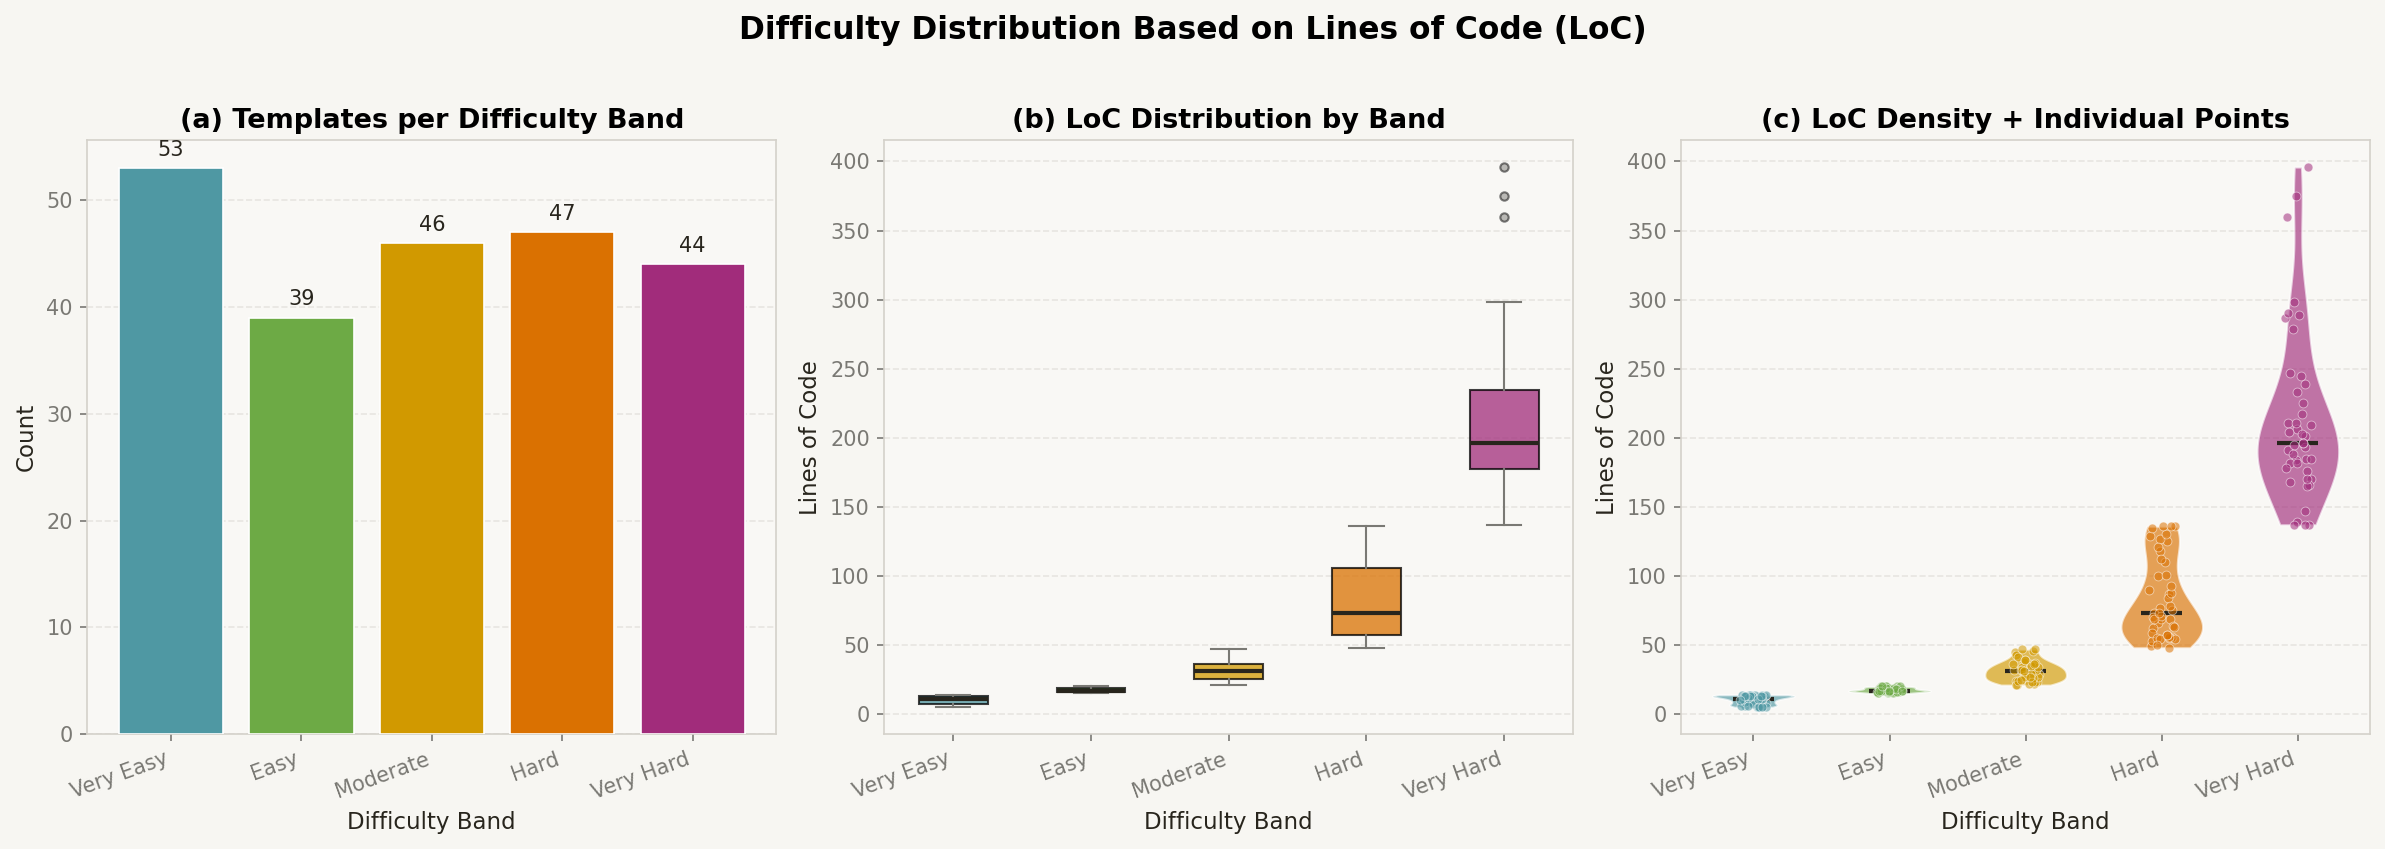

Saved: plot_loc_distribution.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle("Difficulty Distribution Based on Lines of Code (LoC)", fontsize=15, fontweight="bold", y=1.02)
colors = [BAND_COLORS[b] for b in BAND_ORDER]

# ── (a) Count bar chart ───────────────────────────────────────────────────────
ax = axes[0]
counts = df["final_difficulty_band"].value_counts()[BAND_ORDER]
bars = ax.bar(BAND_ORDER, counts, color=colors, edgecolor="white", linewidth=0.8, zorder=3)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=10, color="#28251D")
ax.set_title("(a) Templates per Difficulty Band", fontweight="bold")
ax.set_xlabel("Difficulty Band")
ax.set_ylabel("Count")
ax.set_xticks(range(len(BAND_ORDER)))
ax.set_xticklabels(BAND_ORDER, rotation=20, ha="right")
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)

# ── (b) Box plot of LoC ───────────────────────────────────────────────────────
ax = axes[1]
data_by_band = [df.loc[df["final_difficulty_band"] == b, "loc"].values for b in BAND_ORDER]
bp = ax.boxplot(data_by_band, patch_artist=True, notch=False,
                medianprops=dict(color="#28251D", linewidth=2),
                whiskerprops=dict(color="#7A7974"),
                capprops=dict(color="#7A7974"),
                flierprops=dict(marker="o", markersize=4, markerfacecolor="#7A7974", alpha=0.5),
                zorder=3)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_title("(b) LoC Distribution by Band", fontweight="bold")
ax.set_xlabel("Difficulty Band")
ax.set_ylabel("Lines of Code")
ax.set_xticks(range(1, len(BAND_ORDER) + 1))
ax.set_xticklabels(BAND_ORDER, rotation=20, ha="right")
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)

# ── (c) Violin + strip ────────────────────────────────────────────────────────
ax = axes[2]
for i, (band, color) in enumerate(zip(BAND_ORDER, colors)):
    vals = df.loc[df["final_difficulty_band"] == band, "loc"].values
    parts = ax.violinplot(vals, positions=[i], widths=0.6, showmedians=True,
                          showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
        pc.set_edgecolor("white")
    parts["cmedians"].set_color("#28251D")
    parts["cmedians"].set_linewidth(2)
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, s=18, color=color,
               alpha=0.55, zorder=4, edgecolors="white", linewidths=0.4)
ax.set_title("(c) LoC Density + Individual Points", fontweight="bold")
ax.set_xlabel("Difficulty Band")
ax.set_ylabel("Lines of Code")
ax.set_xticks(range(len(BAND_ORDER)))
ax.set_xticklabels(BAND_ORDER, rotation=20, ha="right")
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_loc_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_loc_distribution.png")


## 3 · Average Template Size by Difficulty Band

A grouped bar chart overlaying three complexity dimensions — average Resources, Parameters, and LoC —
across each difficulty band.  LoC is plotted on a secondary axis (right) because its scale differs
from resource/parameter counts.


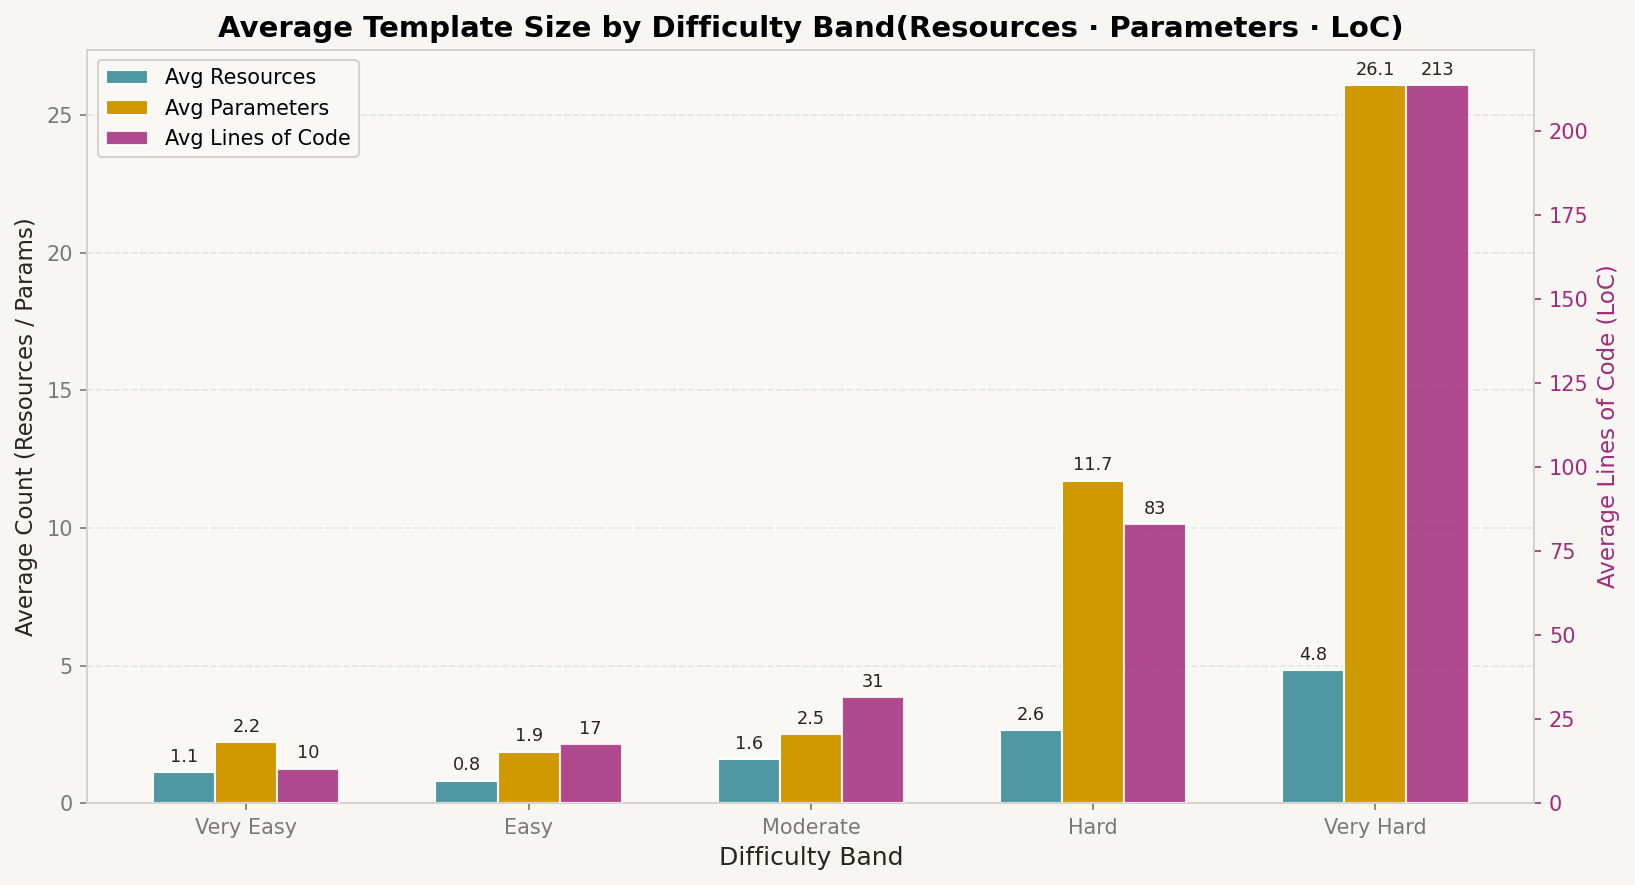

Saved: plot_avg_template_size.png


In [5]:
summary = df.groupby("final_difficulty_band", observed=True).agg(
    avg_resources=("n_resources", "mean"),
    avg_params   =("n_params",    "mean"),
    avg_loc      =("loc",         "mean"),
    avg_tokens   =("tokens",      "mean"),
).reindex(BAND_ORDER).round(2)

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

x   = np.arange(len(BAND_ORDER))
w   = 0.22  # bar width

# Resources & params on left axis
b1 = ax1.bar(x - w, summary["avg_resources"], width=w, label="Avg Resources",
             color="#4f98a3", edgecolor="white", zorder=3)
b2 = ax1.bar(x,     summary["avg_params"],    width=w, label="Avg Params",
             color="#d19900", edgecolor="white", zorder=3)

# LoC on right axis
b3 = ax2.bar(x + w, summary["avg_loc"], width=w, label="Avg LoC",
             color="#a12c7b", edgecolor="white", alpha=0.85, zorder=3)

# Labels on bars
ax1.bar_label(b1, fmt="%.1f", padding=3, fontsize=8.5, color="#28251D")
ax1.bar_label(b2, fmt="%.1f", padding=3, fontsize=8.5, color="#28251D")
ax2.bar_label(b3, fmt="%.0f", padding=3, fontsize=8.5, color="#28251D")

ax1.set_xlabel("Difficulty Band", fontsize=12)
ax1.set_ylabel("Average Count (Resources / Params)", fontsize=11, color="#28251D")
ax2.set_ylabel("Average Lines of Code (LoC)", fontsize=11, color="#a12c7b")
ax2.tick_params(axis="y", colors="#a12c7b")

ax1.set_xticks(x)
ax1.set_xticklabels(BAND_ORDER)
ax1.yaxis.grid(True, zorder=0)
ax1.set_axisbelow(True)

handles = [b1, b2, b3]
labels  = ["Avg Resources", "Avg Parameters", "Avg Lines of Code"]
ax1.legend(handles, labels, loc="upper left", framealpha=0.95)

ax1.set_title("Average Template Size by Difficulty Band(Resources · Parameters · LoC)", fontsize=14, fontweight="bold")
fig.patch.set_facecolor("#F7F6F2")

plt.tight_layout()
plt.savefig("plot_avg_template_size.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_avg_template_size.png")


## 4 · Security Quality by Difficulty Band

**Checkov score** = fraction of static security checks that passed (1.0 = fully secure).  
Harder templates tend to introduce more complex configurations and may expose more misconfigurations.


/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_53771/436971726.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(BAND_ORDER, rotation=20, ha="right")


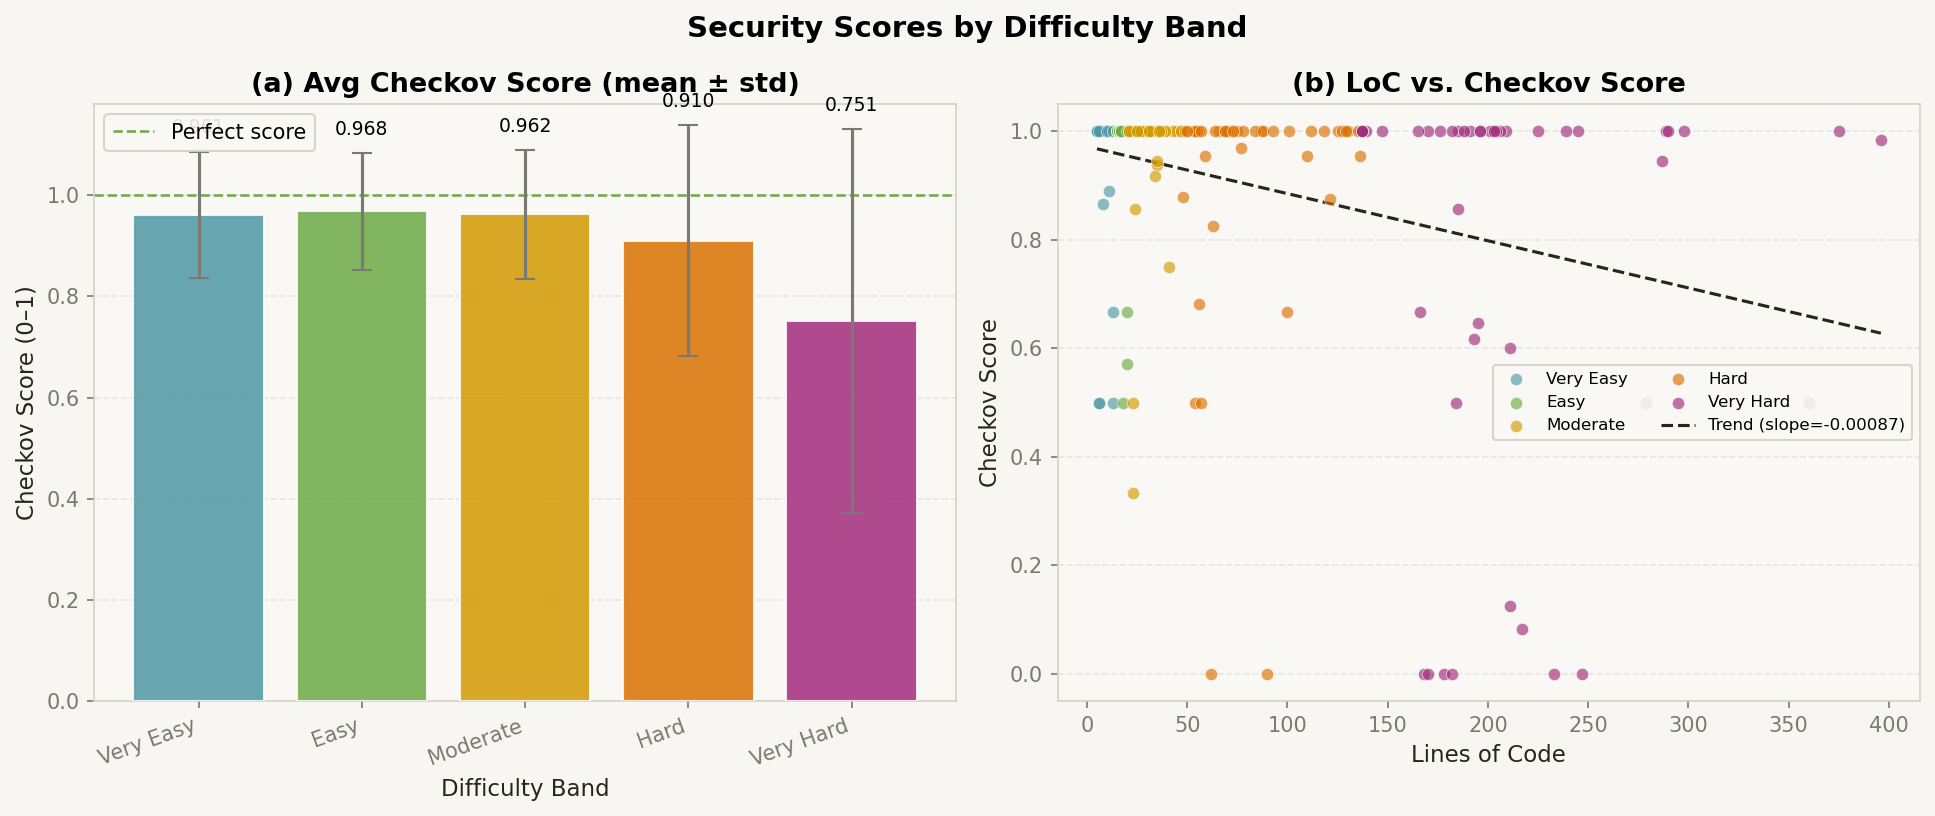

Saved: plot_security_scores.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle("Security Scores by Difficulty Band", fontsize=14, fontweight="bold")

# ── (a) Checkov mean ± std ────────────────────────────────────────────────────
ax = axes[0]
means = df.groupby("final_difficulty_band", observed=True)["checkov_score"].mean().reindex(BAND_ORDER)
stds  = df.groupby("final_difficulty_band", observed=True)["checkov_score"].std().reindex(BAND_ORDER)
bars = ax.bar(BAND_ORDER, means, yerr=stds, capsize=5,
              color=colors, edgecolor="white", alpha=0.85, zorder=3,
              error_kw=dict(ecolor="#7A7974", elinewidth=1.5))
ax.bar_label(bars, fmt="%.3f", padding=7, fontsize=9)
ax.set_ylim(0, 1.18)
ax.set_title("(a) Avg Checkov Score (mean ± std)", fontweight="bold")
ax.set_ylabel("Checkov Score (0–1)")
ax.set_xlabel("Difficulty Band")
ax.set_xticklabels(BAND_ORDER, rotation=20, ha="right")
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.axhline(1.0, color="#6daa45", linestyle="--", linewidth=1.2, label="Perfect score")
ax.legend()

# ── (b) Scatter: LoC vs Checkov ───────────────────────────────────────────────
ax = axes[1]
for band, color in BAND_COLORS.items():
    sub = df[df["final_difficulty_band"] == band]
    ax.scatter(sub["loc"], sub["checkov_score"], c=color, s=35, alpha=0.65,
               label=band, edgecolors="white", linewidths=0.4, zorder=3)
# regression line
mask = df["checkov_score"].notna() & df["loc"].notna()
m, b = np.polyfit(df.loc[mask, "loc"], df.loc[mask, "checkov_score"], 1)
xfit = np.linspace(df["loc"].min(), df["loc"].max(), 200)
ax.plot(xfit, m * xfit + b, color="#28251D", linewidth=1.5, linestyle="--", label=f"Trend (slope={m:.5f})")
ax.set_title("(b) LoC vs. Checkov Score", fontweight="bold")
ax.set_xlabel("Lines of Code")
ax.set_ylabel("Checkov Score")
ax.legend(fontsize=8, ncol=2)
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_security_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_security_scores.png")


## 5 · Complexity Correlation Heatmap

Pairwise Pearson correlations between all numeric complexity and scoring features.


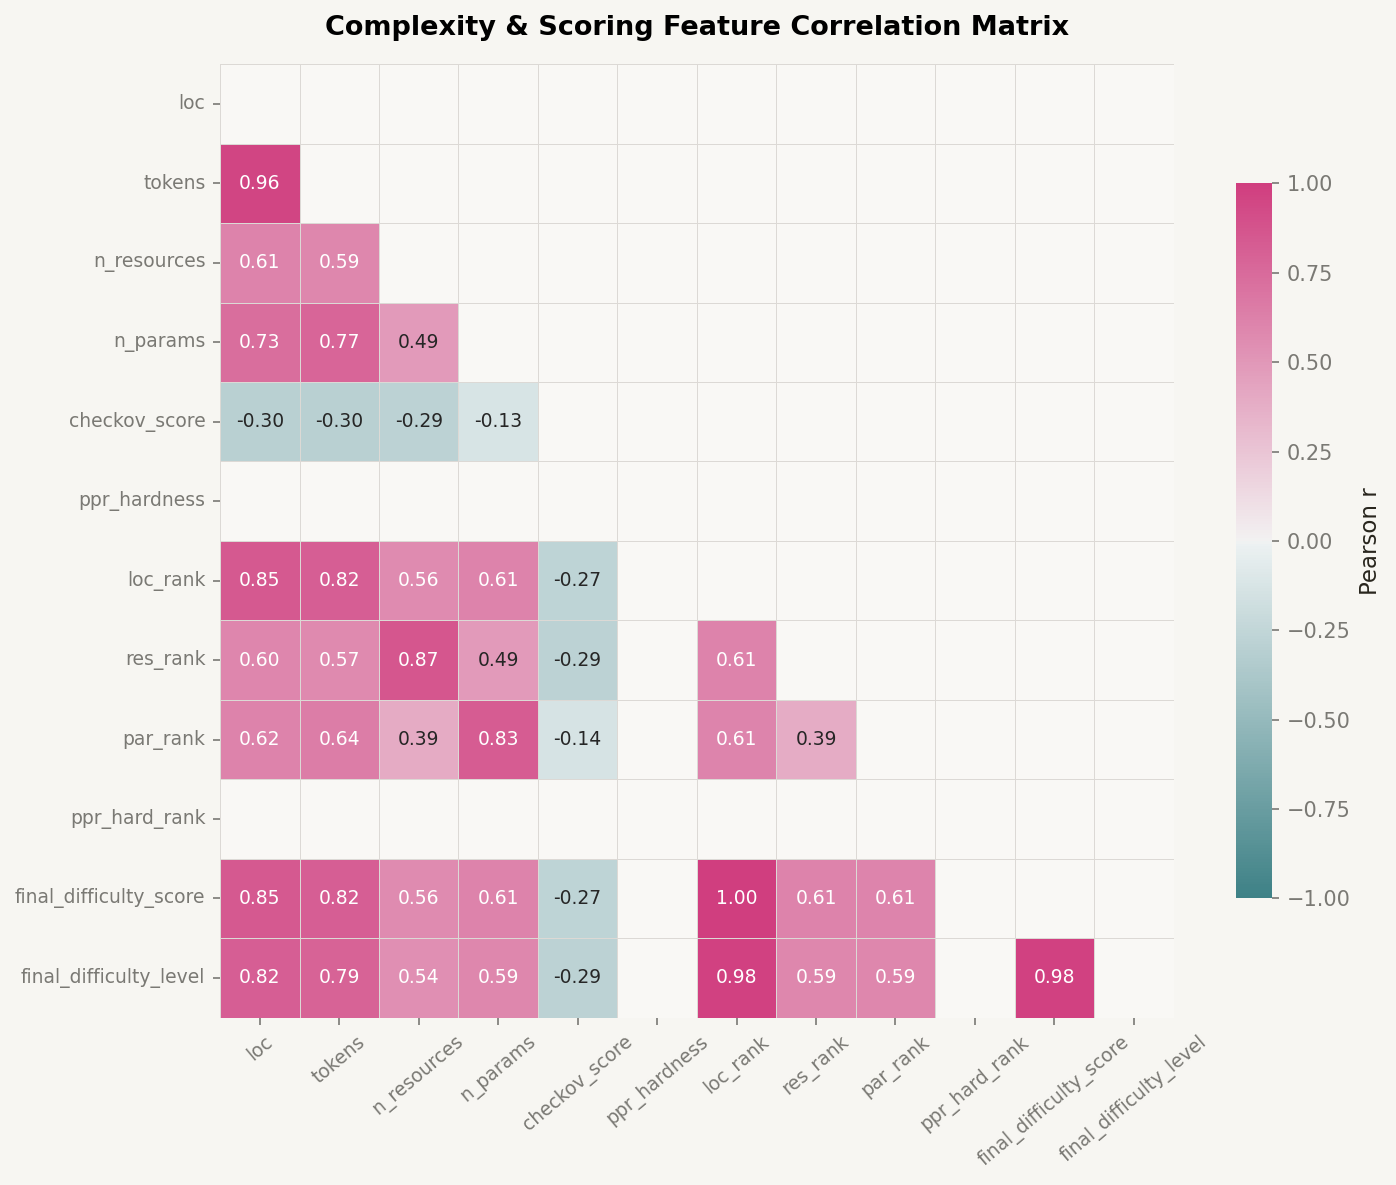

Saved: plot_correlation_heatmap.png


In [7]:
corr_cols = [
    "loc", "tokens", "n_resources", "n_params",
    "checkov_score", "ppr_hardness",
    "loc_rank", "res_rank", "par_rank", "ppr_hard_rank",
    "final_difficulty_score", "final_difficulty_level",
]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(200, 350, s=75, l=50, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    linewidths=0.4, linecolor="#DCD9D5",
    square=True, ax=ax,
    cbar_kws={"shrink": 0.75, "label": "Pearson r"}
)
ax.set_title("Complexity & Scoring Feature Correlation Matrix", fontsize=13, fontweight="bold", pad=14)
ax.tick_params(axis="x", rotation=40, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig("plot_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_correlation_heatmap.png")


## 6 · Composite Difficulty Score Distribution

The `final_difficulty_score` is a composite percentile-rank-weighted score (0–1).  
This histogram shows how templates are spread across score values, coloured by band.


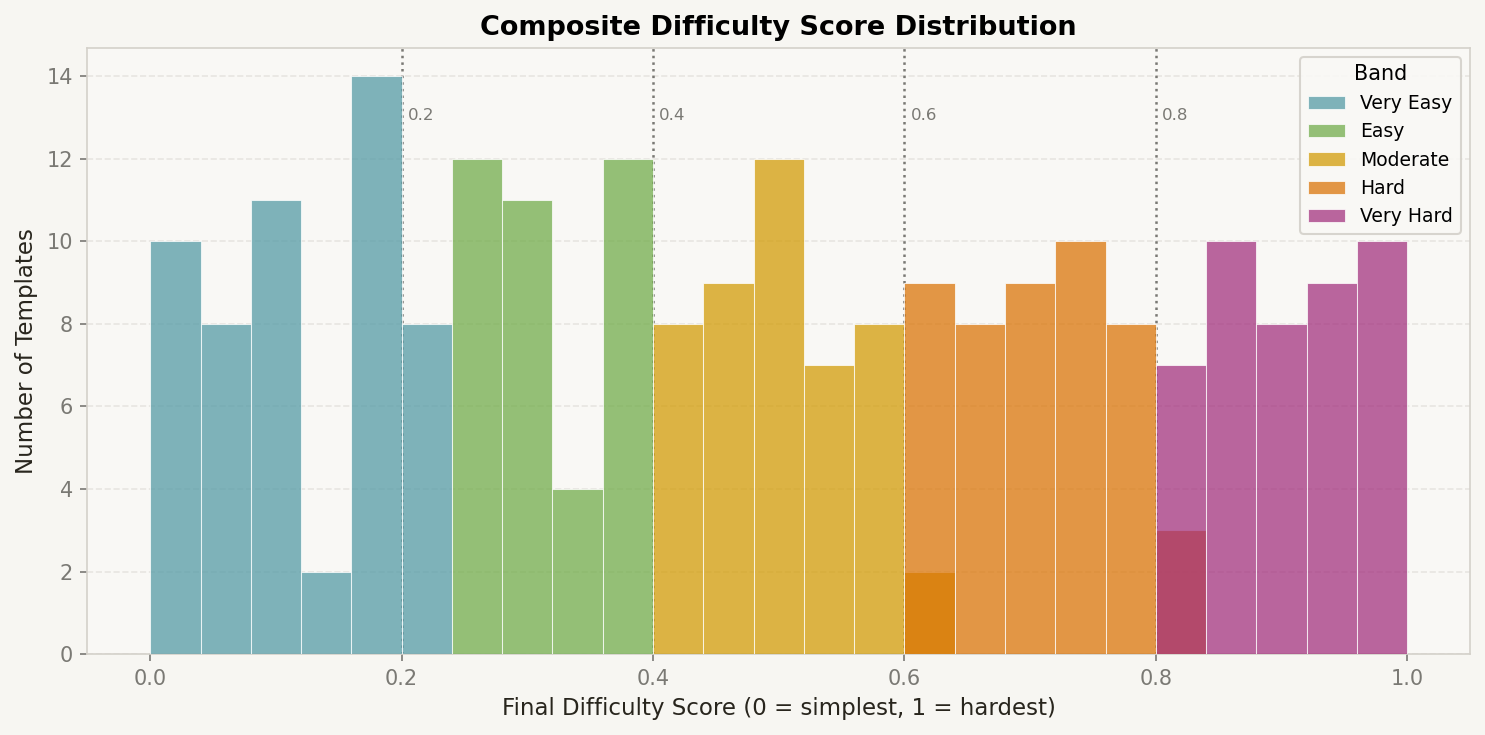

Saved: plot_difficulty_score_hist.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1, 26)
for band, color in BAND_COLORS.items():
    sub = df[df["final_difficulty_band"] == band]
    ax.hist(sub["final_difficulty_score"], bins=bins, color=color, alpha=0.72,
            edgecolor="white", linewidth=0.5, label=band, zorder=3)

# vertical band separators
thresholds = [0.2, 0.4, 0.6, 0.8]
labels_th  = ["0.2", "0.4", "0.6", "0.8"]
for t, lbl in zip(thresholds, labels_th):
    ax.axvline(t, color="#7A7974", linestyle=":", linewidth=1.2)
    ax.text(t + 0.005, ax.get_ylim()[1] * 0.9, lbl,
            fontsize=8, color="#7A7974", va="top")

ax.set_title("Composite Difficulty Score Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Final Difficulty Score (0 = simplest, 1 = hardest)")
ax.set_ylabel("Number of Templates")
ax.legend(title="Band", fontsize=9)
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("plot_difficulty_score_hist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_difficulty_score_hist.png")


## 7 · Scatter Matrix: LoC · Resources · Params · Tokens

A pairwise scatter plot of the four raw complexity metrics, coloured by difficulty band.  
Observe how *Very Hard* templates cluster in the high-LoC, high-params corner.


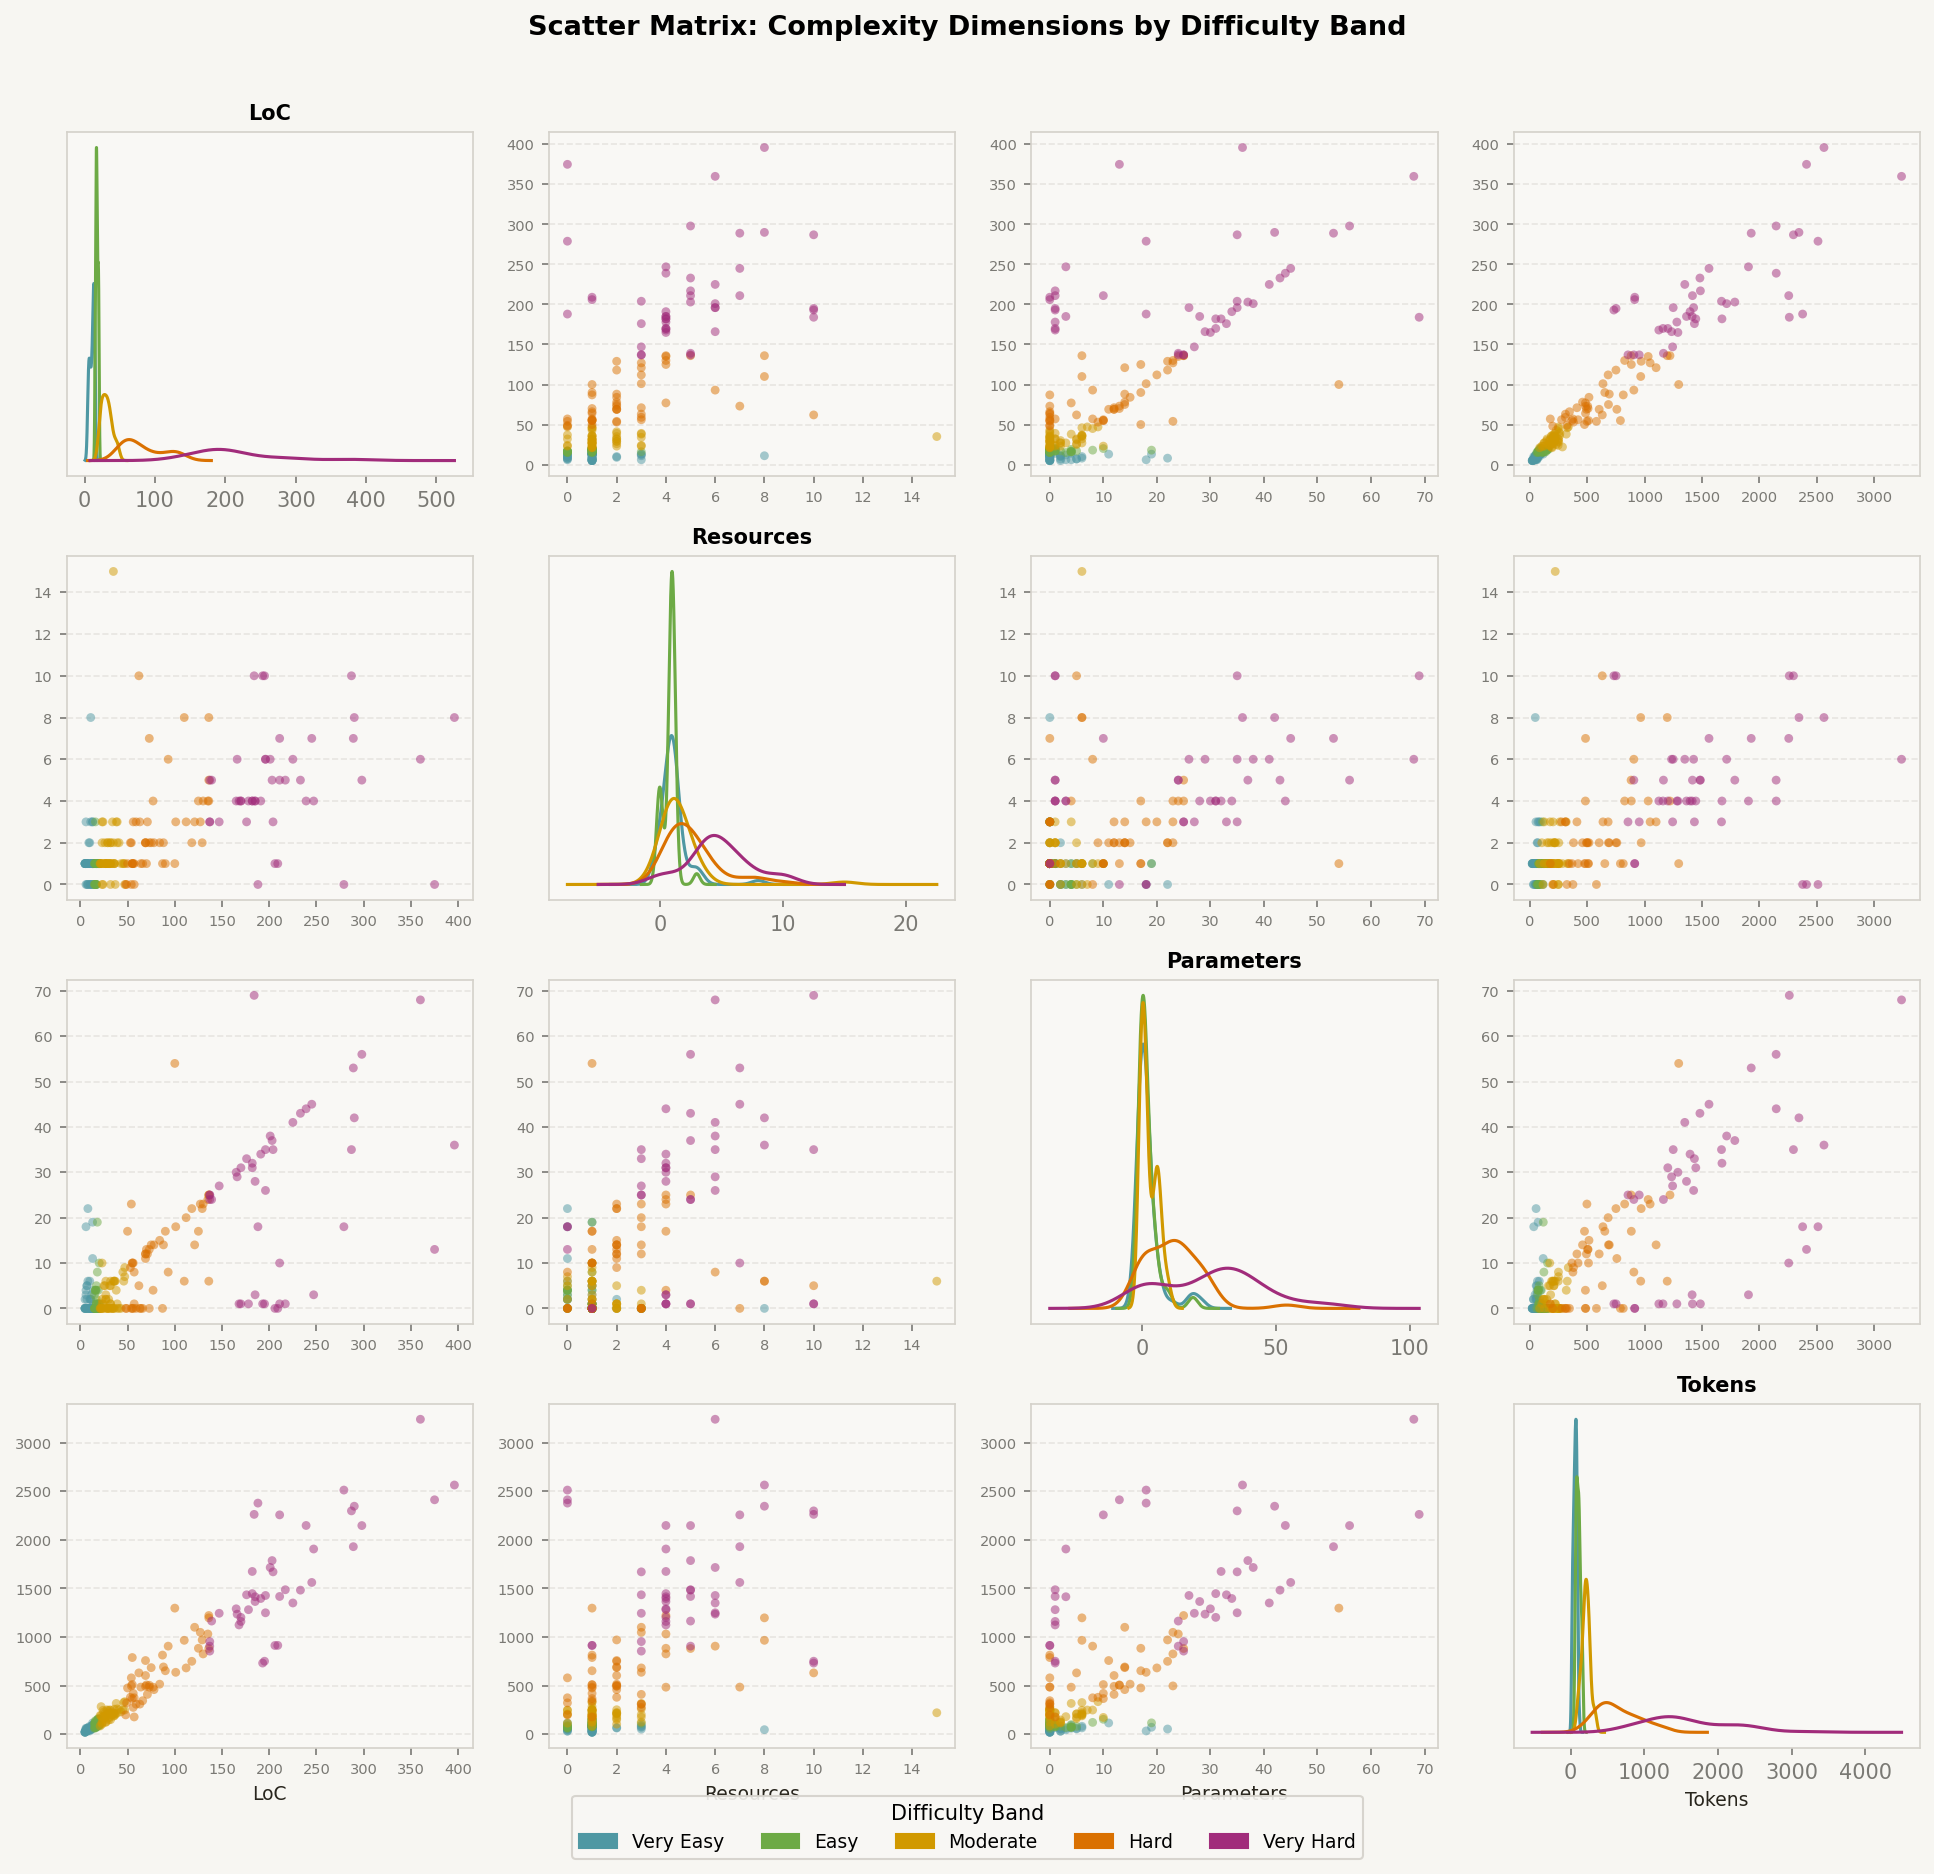

Saved: plot_scatter_matrix.png


In [9]:
from pandas.plotting import scatter_matrix
import matplotlib.colors as mcolors

cols_scatter = ["loc", "n_resources", "n_params", "tokens"]
col_labels   = ["LoC", "Resources", "Parameters", "Tokens"]

fig, axes = plt.subplots(4, 4, figsize=(13, 12))

for i, col_y in enumerate(cols_scatter):
    for j, col_x in enumerate(cols_scatter):
        ax = axes[i][j]
        if i == j:
            # Diagonal: KDE per band
            for band, color in BAND_COLORS.items():
                vals = df.loc[df["final_difficulty_band"] == band, col_x].dropna()
                if len(vals) > 2:
                    vals.plot.kde(ax=ax, color=color, linewidth=1.5)
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.set_title(col_labels[i], fontsize=10, fontweight="bold")
            ax.yaxis.set_visible(False)
        else:
            for band, color in BAND_COLORS.items():
                sub = df[df["final_difficulty_band"] == band]
                ax.scatter(sub[col_x], sub[col_y], c=color, s=18, alpha=0.5,
                           edgecolors="none", zorder=3)
            ax.tick_params(labelsize=7)
        if i == 3: ax.set_xlabel(col_labels[j], fontsize=9)
        if j == 0 and i != i: ax.set_ylabel(col_labels[i], fontsize=9)
        ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# Legend
legend_handles = [mpatches.Patch(color=c, label=b) for b, c in BAND_COLORS.items()]
fig.legend(handles=legend_handles, title="Difficulty Band", loc="lower center",
           ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Scatter Matrix: Complexity Dimensions by Difficulty Band",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_scatter_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_scatter_matrix.png")


## 8 · Rank Component Breakdown by Difficulty Band

The composite difficulty score is derived from four percentile ranks:  
**LoC rank · Resource rank · Parameter rank · PPR Hardness rank**.  
This stacked bar shows how each component contributes to the average score per band.


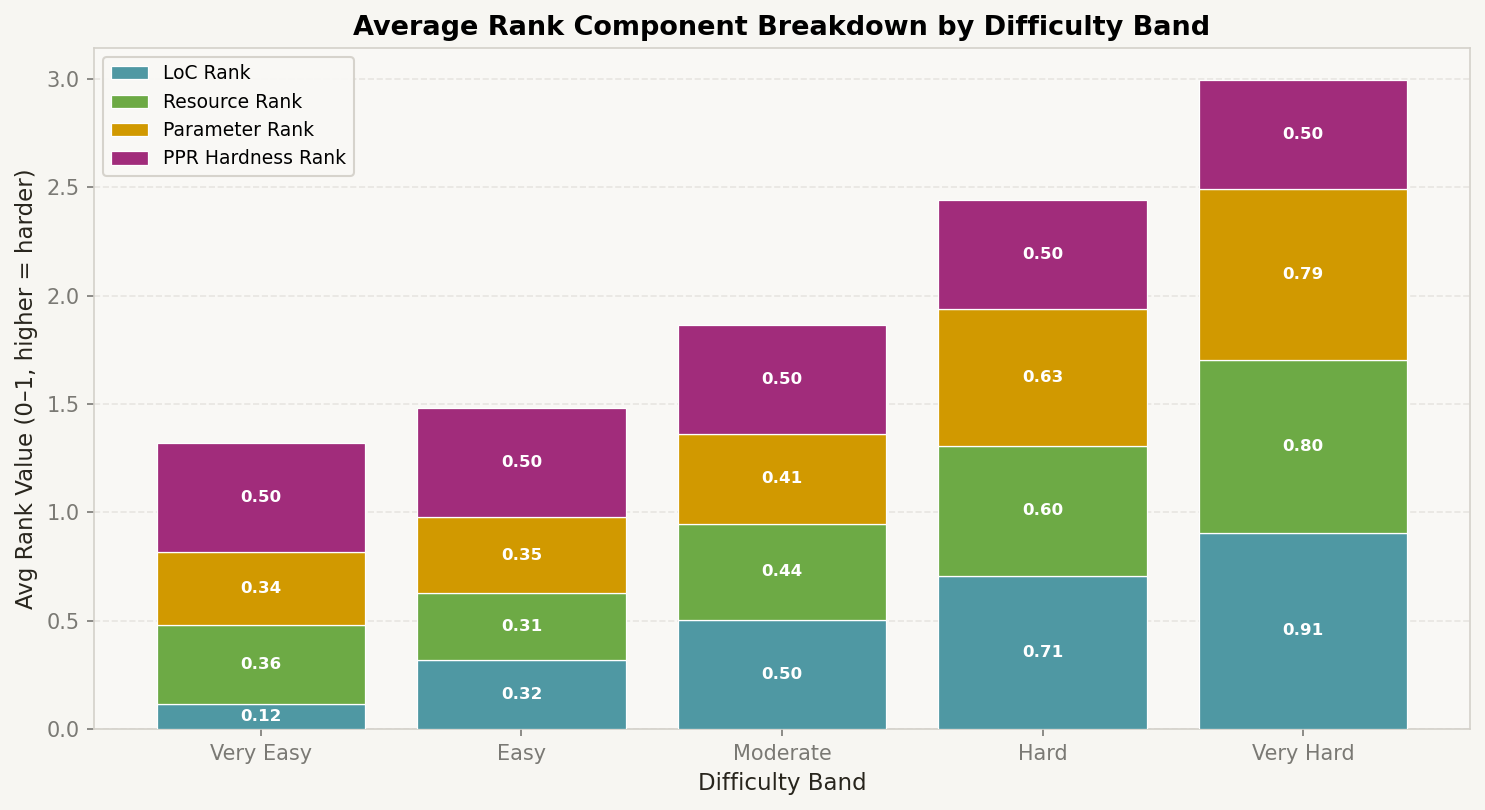

Saved: plot_rank_breakdown.png


In [10]:
rank_cols = {
    "loc_rank":       "#4f98a3",
    "res_rank":       "#6daa45",
    "par_rank":       "#d19900",
    "ppr_hard_rank":  "#a12c7b",
}
rank_labels = {
    "loc_rank": "LoC Rank",
    "res_rank": "Resource Rank",
    "par_rank": "Parameter Rank",
    "ppr_hard_rank": "PPR Hardness Rank",
}

ranks_by_band = df.groupby("final_difficulty_band", observed=True)[list(rank_cols.keys())].mean().reindex(BAND_ORDER)

fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(len(BAND_ORDER))
for col, color in rank_cols.items():
    vals = ranks_by_band[col].values
    bars = ax.bar(BAND_ORDER, vals, bottom=bottom, color=color, edgecolor="white",
                  linewidth=0.6, label=rank_labels[col], zorder=3)
    # Label segments if tall enough
    for rect, val, bot in zip(bars, vals, bottom):
        if val > 0.04:
            ax.text(rect.get_x() + rect.get_width() / 2,
                    bot + val / 2, f"{val:.2f}",
                    ha="center", va="center", fontsize=8, color="white", fontweight="600")
    bottom += vals

ax.set_title("Average Rank Component Breakdown by Difficulty Band", fontsize=13, fontweight="bold")
ax.set_xlabel("Difficulty Band")
ax.set_ylabel("Avg Rank Value (0–1, higher = harder)")
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("plot_rank_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_rank_breakdown.png")


## 9 · Tokens vs. LoC — Token Density Analysis

Tokens per line (token density) can reveal templates that are syntactically rich but short,
or verbose with low token density.


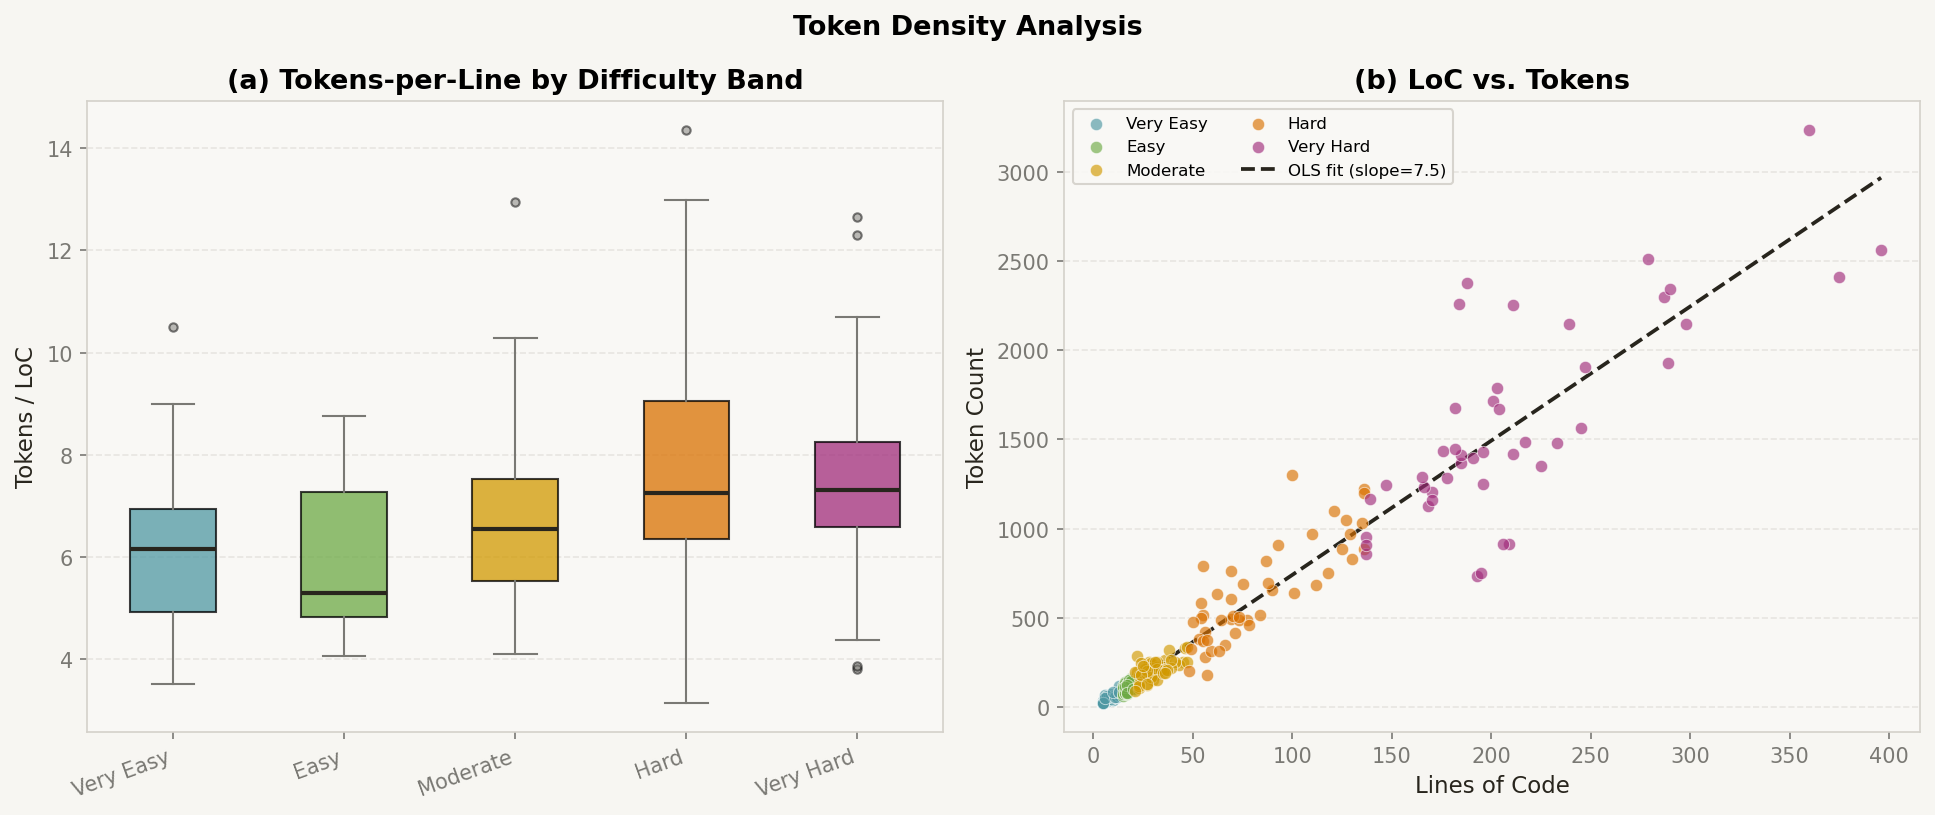

Saved: plot_token_density.png


In [11]:
df["token_density"] = df["tokens"] / df["loc"].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle("Token Density Analysis", fontsize=13, fontweight="bold")

# ── (a) Token density box ─────────────────────────────────────────────────────
ax = axes[0]
data_td = [df.loc[df["final_difficulty_band"] == b, "token_density"].dropna().values for b in BAND_ORDER]
bp = ax.boxplot(data_td, patch_artist=True, notch=False,
                medianprops=dict(color="#28251D", linewidth=2),
                whiskerprops=dict(color="#7A7974"),
                capprops=dict(color="#7A7974"),
                flierprops=dict(marker="o", markersize=4, markerfacecolor="#7A7974", alpha=0.5),
                zorder=3)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_title("(a) Tokens-per-Line by Difficulty Band", fontweight="bold")
ax.set_xticklabels(BAND_ORDER, rotation=20, ha="right")
ax.set_ylabel("Tokens / LoC")
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

# ── (b) Scatter: LoC vs Tokens ────────────────────────────────────────────────
ax = axes[1]
for band, color in BAND_COLORS.items():
    sub = df[df["final_difficulty_band"] == band]
    ax.scatter(sub["loc"], sub["tokens"], c=color, s=35, alpha=0.65,
               label=band, edgecolors="white", linewidths=0.4, zorder=3)
m2, b2 = np.polyfit(df["loc"], df["tokens"], 1)
xfit2  = np.linspace(df["loc"].min(), df["loc"].max(), 200)
ax.plot(xfit2, m2 * xfit2 + b2, color="#28251D", linewidth=1.8, linestyle="--",
        label=f"OLS fit (slope={m2:.1f})")
ax.set_title("(b) LoC vs. Tokens", fontweight="bold")
ax.set_xlabel("Lines of Code")
ax.set_ylabel("Token Count")
ax.legend(fontsize=8, ncol=2)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_token_density.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_token_density.png")


## 10 · Licence Distribution

Understanding the licencing landscape of the benchmark corpus —
important for reproducibility and open publication.


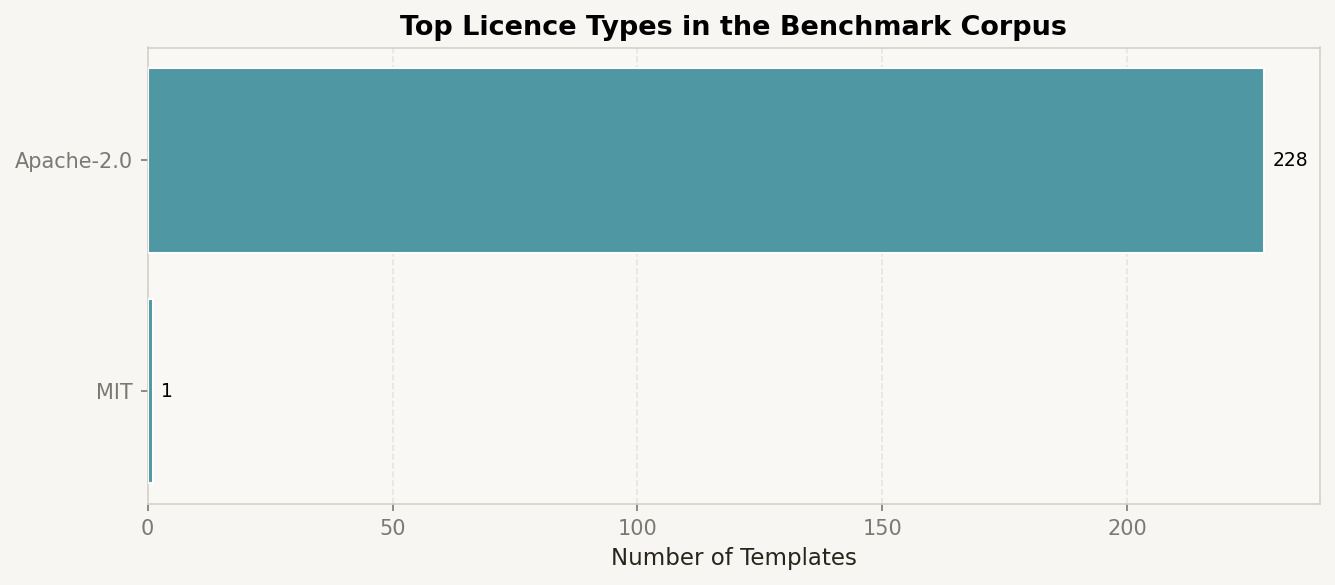

Saved: plot_licence_distribution.png


In [12]:
lic_counts = df["licence_spdx"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(lic_counts.index[::-1], lic_counts.values[::-1],
               color="#4f98a3", edgecolor="white", zorder=3)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=9)
ax.set_title("Top Licence Types in the Benchmark Corpus", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Templates")
ax.xaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("plot_licence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_licence_distribution.png")


## 11 · Summary Statistics Table by Difficulty Band


In [ ]:
summary_full = df.groupby("final_difficulty_band", observed=True).agg(
    N           =("loc",                  "count"),
    LoC_Mean    =("loc",                  "mean"),
    LoC_Med     =("loc",                  "median"),
    LoC_Std     =("loc",                  "std"),
    Resources   =("n_resources",          "mean"),
    Params      =("n_params",             "mean"),
    Tokens      =("tokens",               "mean"),
    Checkov     =("checkov_score",        "mean"),
    Diff_Score  =("final_difficulty_score","mean"),
).reindex(BAND_ORDER).round(2)

display(summary_full.style
    .background_gradient(cmap="YlOrRd", subset=["Diff_Score", "LoC_Mean"])
    .format(precision=2)
    .set_caption("Summary Statistics by Difficulty Band")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("padding-bottom", "6px")]},
        {"selector": "th", "props": [("background-color", "#CEDCD8"), ("color", "#28251D")]},
    ])
)


KeyError: "Column(s) ['trivy_score'] do not exist"